In [4]:
import pandas as pd
import mysql.connector
import os

# List of CSV files and their corresponding table names
csv_files = [
    ('customers.csv', 'customers'),
    ('orders.csv', 'orders'),
    ('sellers.csv', 'sellers'),
    ('products.csv', 'products'),
    ('geolocation.csv', 'geolocation'),
    ('payments.csv', 'payments'),
    ('order_items.csv', 'order_items')# Added payments.csv for specific handling
]

# Connect to the MySQL database
conn = mysql.connector.connect(
    port = '3307',
    host='localhost',
    user='root',
    password='Chunmun@1905',
    database='ecommerce'
)
cursor = conn.cursor()

# Folder containing the CSV files
folder_path = 'C:\\Users\\sukra\\OneDrive\\Desktop\\datasets'

def get_sql_type(dtype):
    if pd.api.types.is_integer_dtype(dtype):
        return 'INT'
    elif pd.api.types.is_float_dtype(dtype):
        return 'FLOAT'
    elif pd.api.types.is_bool_dtype(dtype):
        return 'BOOLEAN'
    elif pd.api.types.is_datetime64_any_dtype(dtype):
        return 'DATETIME'
    else:
        return 'TEXT'

for csv_file, table_name in csv_files:
    file_path = os.path.join(folder_path, csv_file)
    
    # Read the CSV file into a pandas DataFrame
    df = pd.read_csv(file_path)
    
    # Replace NaN with None to handle SQL NULL
    df = df.where(pd.notnull(df), None)
    
    # Debugging: Check for NaN values
    print(f"Processing {csv_file}")
    print(f"NaN values before replacement:\n{df.isnull().sum()}\n")

    # Clean column names
    df.columns = [col.replace(' ', '_').replace('-', '_').replace('.', '_') for col in df.columns]

    # Generate the CREATE TABLE statement with appropriate data types
    columns = ', '.join([f'`{col}` {get_sql_type(df[col].dtype)}' for col in df.columns])
    create_table_query = f'CREATE TABLE IF NOT EXISTS `{table_name}` ({columns})'
    cursor.execute(create_table_query)

    # Insert DataFrame data into the MySQL table
    for _, row in df.iterrows():
        # Convert row to tuple and handle NaN/None explicitly
        values = tuple(None if pd.isna(x) else x for x in row)
        sql = f"INSERT INTO `{table_name}` ({', '.join(['`' + col + '`' for col in df.columns])}) VALUES ({', '.join(['%s'] * len(row))})"
        cursor.execute(sql, values)

    # Commit the transaction for the current CSV file
    conn.commit()

# Close the connection
conn.close()

Processing customers.csv
NaN values before replacement:
customer_id                 0
customer_unique_id          0
customer_zip_code_prefix    0
customer_city               0
customer_state              0
dtype: int64

Processing orders.csv
NaN values before replacement:
order_id                            0
customer_id                         0
order_status                        0
order_purchase_timestamp            0
order_approved_at                 160
order_delivered_carrier_date     1783
order_delivered_customer_date    2965
order_estimated_delivery_date       0
dtype: int64

Processing sellers.csv
NaN values before replacement:
seller_id                 0
seller_zip_code_prefix    0
seller_city               0
seller_state              0
dtype: int64

Processing products.csv
NaN values before replacement:
product_id                      0
product category              610
product_name_length           610
product_description_length    610
product_photos_qty            610
prod

In [5]:
import matplotlib.pyplot as plt
import seaborn as sns
db = mysql.connector.connect(port = '3307', host='localhost', username='root',password='Chunmun@1905',database='ecommerce')
cur = db.cursor()

In [6]:
#list of unique cities where customers are located

query = """select distinct customer_city from customers"""
cur.execute(query)
data = cur.fetchall()
data

[('franca',),
 ('sao bernardo do campo',),
 ('sao paulo',),
 ('mogi das cruzes',),
 ('campinas',),
 ('jaragua do sul',),
 ('timoteo',),
 ('curitiba',),
 ('belo horizonte',),
 ('montes claros',),
 ('rio de janeiro',),
 ('lencois paulista',),
 ('caxias do sul',),
 ('piracicaba',),
 ('guarulhos',),
 ('pacaja',),
 ('florianopolis',),
 ('aparecida de goiania',),
 ('santo andre',),
 ('goiania',),
 ('cachoeiro de itapemirim',),
 ('sao jose dos campos',),
 ('sao roque',),
 ('camacari',),
 ('resende',),
 ('sumare',),
 ('novo hamburgo',),
 ('sao luis',),
 ('sao jose',),
 ('santa barbara',),
 ('ribeirao preto',),
 ('ituiutaba',),
 ('taquarituba',),
 ('sao jose dos pinhais',),
 ('barrinha',),
 ('parati',),
 ('dourados',),
 ('trindade',),
 ('cascavel',),
 ('fortaleza',),
 ('brasilia',),
 ('pelotas',),
 ('porto alegre',),
 ('salto',),
 ('jundiai',),
 ('cacapava',),
 ('sao vicente',),
 ('uberlandia',),
 ('botelhos',),
 ('sao goncalo',),
 ('araucaria',),
 ('nova iguacu',),
 ('areia branca',),
 ('campo

In [7]:
#number of orders placed in 2017

query = """select count(order_id) from orders where year(order_purchase_timestamp) = 2017"""
cur.execute(query)
data = cur.fetchall()
data

[(45101,)]

In [9]:
#total sales per category

query = """select products.product_category category, round(sum(payments.payment_value),2) sales from products
join order_items
on products.product_id = order_items.product_id
join payments
on payments.order_id = order_items.order_id
group by category """
cur.execute(query)
data = cur.fetchall()
data

[('perfumery', 506738.66),
 ('Furniture Decoration', 1430176.39),
 ('telephony', 486882.05),
 ('Fashion Bags and Accessories', 218158.28),
 ('bed table bath', 1712553.67),
 ('automotive', 852294.33),
 ('computer accessories', 1585330.45),
 ('housewares', 1094758.13),
 ('babies', 539845.66),
 ('toys', 619037.69),
 ('Furniture office', 646826.49),
 ('Cool Stuff', 779698.0),
 ('HEALTH BEAUTY', 1657373.12),
 ('pet Shop', 311268.97),
 ('General Interest Books', 64694.76),
 ('stationary store', 317440.07),
 ('Watches present', 1429216.68),
 ('PCs', 279121.55),
 ('climatization', 91170.66),
 ('Construction Tools Construction', 241475.63),
 ('sport leisure', 1392127.56),
 ('Bags Accessories', 187151.29),
 ('electronics', 259857.1),
 ('Casa Construcao', 136645.29),
 ('Games consoles', 195480.38),
 ('home appliances', 95532.27),
 ('Garden tools', 838280.75),
 ('Agro Industria e Comercio', 118730.61),
 (None, 252801.71),
 ('audio', 60324.62),
 ('technical books', 24915.44),
 ('Construction Tools 

In [12]:
df = pd.DataFrame(data, columns = ['Category','Sales'])

In [13]:
df

,Category,Sales
0,perfumery,506738.66
1,Furniture Decoration,1430176.39
2,telephony,486882.05
3,Fashion Bags and Accessories,218158.28
4,bed table bath,1712553.67
...,...,...
69,cds music dvds,1199.43
70,La Cuisine,2913.53
71,Fashion Children's Clothing,785.67
72,PC Gamer,2174.43


In [16]:
#orders paid in installments
query = """select (select count(payment_installments) from payments where payment_installments>=1)/count(*)*100 from payments"""
cur.execute(query)
data = cur.fetchall()
data

[(Decimal('99.9981'),)]

In [18]:
#number of customers from each state

query = """select customer_state, count(customer_id) from customers group by customer_state"""
cur.execute(query)
data = cur.fetchall()
data

[('SP', 41746),
 ('SC', 3637),
 ('MG', 11635),
 ('PR', 5045),
 ('RJ', 12852),
 ('RS', 5466),
 ('PA', 975),
 ('GO', 2020),
 ('ES', 2033),
 ('BA', 3380),
 ('MA', 747),
 ('MS', 715),
 ('CE', 1336),
 ('DF', 2140),
 ('RN', 485),
 ('PE', 1652),
 ('MT', 907),
 ('AM', 148),
 ('AP', 68),
 ('AL', 413),
 ('RO', 253),
 ('PB', 536),
 ('TO', 280),
 ('PI', 495),
 ('AC', 81),
 ('SE', 350),
 ('RR', 46)]

In [27]:
cust_in_state = pd.DataFrame(data, columns=['State','Count'])
cust_in_state = cust_in_state.sort_values(by = 'Count', ascending=False)
cust_in_state 

,State,Count
0,SP,41746
4,RJ,12852
2,MG,11635
5,RS,5466
3,PR,5045
1,SC,3637
9,BA,3380
13,DF,2140
8,ES,2033
7,GO,2020


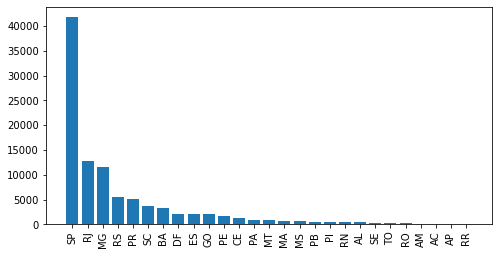

In [29]:
plt.figure(figsize = (8,4))
plt.bar(cust_in_state.State, cust_in_state.Count)
plt.xticks(rotation = 90)
plt.show()

In [ ]:
#number of orders per month in 2018


In [36]:
query = """select monthname(order_purchase_timestamp) month, count(order_id) count_order from orders where year(order_purchase_timestamp) = 2018 group by month """
cur.execute(query)
data = cur.fetchall()
data



[('July', 6292),
 ('August', 6512),
 ('February', 6728),
 ('June', 6167),
 ('March', 7211),
 ('January', 7269),
 ('May', 6873),
 ('April', 6939),
 ('September', 16),
 ('October', 4)]

In [37]:
orders_per_month = pd.DataFrame(data, columns=['Months','Count'])
orders_per_month

,Months,Count
0,July,6292
1,August,6512
2,February,6728
3,June,6167
4,March,7211
5,January,7269
6,May,6873
7,April,6939
8,September,16
9,October,4


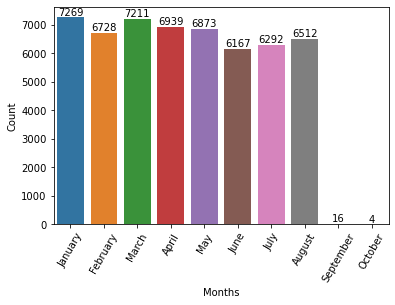

In [43]:
month_order = ['January','February','March','April','May','June','July','August','September','October'] 
ax = sns.barplot(x=orders_per_month.Months, y=orders_per_month.Count, order=month_order)
ax.bar_label(ax.containers[0])
plt.xticks(rotation = 60)
plt.show()

In [44]:
#Average number of products per order according to customer city

In [53]:
query = """with product_count as
(select orders.order_id, orders.customer_id, count(order_items.order_id) as c_order
from orders join order_items
on orders.order_id = order_items.order_id
group by orders.order_id, orders.customer_id)
select customers.customer_city, avg(product_count.c_order) as avg_prod
from customers join product_count
on customers.customer_id = product_count.customer_id
group by customers.customer_city order by avg_prod desc
"""
cur.execute(query)
data = cur.fetchall()
data

[('padre carvalho', Decimal('7.0000')),
 ('celso ramos', Decimal('6.5000')),
 ('candido godoi', Decimal('6.0000')),
 ('datas', Decimal('6.0000')),
 ('matias olimpio', Decimal('5.0000')),
 ('morro de sao paulo', Decimal('4.0000')),
 ('cidelandia', Decimal('4.0000')),
 ('picarra', Decimal('4.0000')),
 ('teixeira soares', Decimal('4.0000')),
 ('curralinho', Decimal('4.0000')),
 ('inconfidentes', Decimal('3.5000')),
 ('ipua', Decimal('3.2500')),
 ('alto paraiso de goias', Decimal('3.0000')),
 ('capela', Decimal('3.0000')),
 ('ubata', Decimal('3.0000')),
 ('nova esperanca do sul', Decimal('3.0000')),
 ('pedregulho', Decimal('3.0000')),
 ('ouvidor', Decimal('3.0000')),
 ('jose boiteux', Decimal('3.0000')),
 ('pacuja', Decimal('3.0000')),
 ('brasileia', Decimal('3.0000')),
 ('chapadao do lageado', Decimal('3.0000')),
 ('buriti', Decimal('3.0000')),
 ('colonia castrolanda', Decimal('2.6667')),
 ('ubajara', Decimal('2.6667')),
 ('maracana', Decimal('2.5000')),
 ('colonia jordaozinho', Decimal('

In [54]:
prod_by_city = pd.DataFrame(data, columns=['City','Avg_Product_Count'])
prod_by_city

,City,Avg_Product_Count
0,padre carvalho,7.0000
1,celso ramos,6.5000
2,candido godoi,6.0000
3,datas,6.0000
4,matias olimpio,5.0000
...,...,...
4105,sebastiao leal,1.0000
4106,morro agudo de goias,1.0000
4107,santa filomena,1.0000
4108,guamiranga,1.0000


In [59]:
#correlation of product price and number of times it was purchased

query = """select upper(products.product_category), count(order_items.product_id), round(avg(order_items.price),2)
from products
join order_items
on products.product_id = order_items.product_id
group by products.product_category"""
cur.execute(query)
data = cur.fetchall()
data

[('HEALTH BEAUTY', 9670, 130.16),
 ('SPORT LEISURE', 8641, 114.34),
 ('COOL STUFF', 3796, 167.36),
 ('COMPUTER ACCESSORIES', 7827, 116.51),
 ('WATCHES PRESENT', 5991, 201.14),
 ('HOUSEWARES', 6964, 90.79),
 ('ELECTRONICS', 2767, 57.91),
 (None, 1603, 112.0),
 ('TOYS', 4117, 117.55),
 ('BED TABLE BATH', 11115, 93.3),
 ('GAMES CONSOLES', 1137, 138.49),
 ('AUTOMOTIVE', 4235, 139.96),
 ('FURNITURE DECORATION', 8334, 87.56),
 ('HOME APPLIANCES', 771, 103.98),
 ('TELEPHONY', 4545, 71.21),
 ('CONSTRUCTION TOOLS CONSTRUCTION', 929, 155.73),
 ('PERFUMERY', 3419, 116.74),
 ('STATIONARY STORE', 2517, 91.75),
 ('ROOM FURNITURE', 503, 137.01),
 ('FASHION BAGS AND ACCESSORIES', 2031, 75.25),
 ('GARDEN TOOLS', 4347, 111.63),
 ('FASHION UNDERWEAR AND BEACH FASHION', 131, 72.84),
 ('PET SHOP', 1947, 110.07),
 ('SIGNALIZATION AND SAFETY', 199, 108.09),
 ('ELECTRICES 2', 238, 476.12),
 ("FASHION WOMEN'S CLOTHING", 48, 58.41),
 ('BAGS ACCESSORIES', 1092, 128.6),
 ('GENERAL INTEREST BOOKS', 553, 84.73),
 (

In [60]:
corr_price_purchase = pd.DataFrame(data, columns=['Product','Order_Count','Avg_Price'])
corr_price_purchase

,Product,Order_Count,Avg_Price
0,HEALTH BEAUTY,9670,130.16
1,SPORT LEISURE,8641,114.34
2,COOL STUFF,3796,167.36
3,COMPUTER ACCESSORIES,7827,116.51
4,WATCHES PRESENT,5991,201.14
...,...,...,...
69,FLOWERS,33,33.64
70,KITCHEN PORTABLE AND FOOD COACH,15,264.57
71,HOUSE COMFORT 2,30,25.34
72,CITTE AND UPHACK FURNITURE,38,114.95


In [64]:
corr_price_purchase.corr(method = 'pearson')

,Order_Count,Avg_Price
Order_Count,1.000000,-0.106315
Avg_Price,-0.106315,1.000000


In [68]:
# Revenue generated by each seller

query = """select *, dense_rank() over(order by revenue desc) from
(select order_items.seller_id, sum(payments.payment_value) as revenue
from order_items 
join payments
on order_items.order_id = payments.order_id
group by order_items.seller_id) as revenue"""
cur.execute(query)
data = cur.fetchall()
data

[('7c67e1448b00f6e969d365cea6b010ab', 507166.9073021412, 1),
 ('1025f0e2d44d7041d6cf58b6550e0bfa', 308222.0398402214, 2),
 ('4a3ca9315b744ce9f8e9374361493884', 301245.26976528764, 3),
 ('1f50f920176fa81dab994f9023523100', 290253.42012761533, 4),
 ('53243585a1d6dc2643021fd1853d8905', 284903.0804977417, 5),
 ('da8622b14eb17ae2831f4ac5b9dab84a', 272219.31931465864, 6),
 ('4869f7a5dfa277a7dca6462dcf3b52b2', 264166.1209387779, 7),
 ('955fee9216a65b617aa5c0531780ce60', 236322.30050226487, 8),
 ('fa1c13f2614d7b5c4749cbc52fecda94', 206513.22986984253, 9),
 ('7e93a43ef30c4f03f38b393420bc753a', 185134.20970630646, 10),
 ('6560211a19b47992c3666cc44a7e94c0', 179657.74904833734, 11),
 ('7a67c85e85bb2ce8582c35f2203ad736', 169030.80002561212, 12),
 ('25c5c91f63607446a97b143d2d535d31', 160534.7397725582, 13),
 ('a1043bafd471dff536d0c462352beb48', 154356.91018915176, 14),
 ('46dc3b2cc0980fb8ec44634e21d2718e', 148864.3400707245, 15),
 ('b37c4c02bda3161a7546a4e6d222d5b2', 145319.04013061523, 16),
 ('620c

In [76]:
rev = pd.DataFrame(data, columns=['Seller_ID','Revenue','Rank'])
rev = rev.head(10)

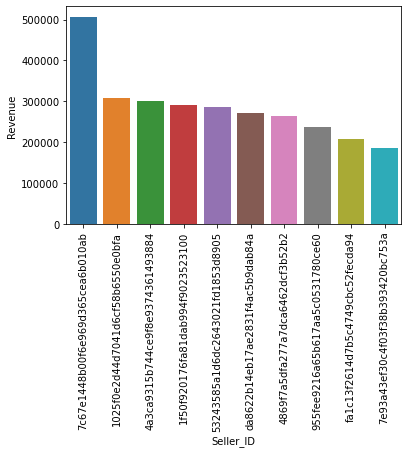

In [80]:
sns.barplot(x = rev['Seller_ID'], y =rev['Revenue'], data = rev.head(10))
plt.xticks(rotation = 90)
plt.show()

In [92]:
#Cumulative sum of sales per month every year

query = """select years, months,payment, sum(payment) over(order by years, months)
from
(select year(orders.order_purchase_timestamp) as years, 
month(orders.order_purchase_timestamp) as months,
round(sum(payments.payment_value),2) as payment from orders
join payments 
on orders.order_id = payments.order_id
group by years, months order by years, months) as a"""
cur.execute(query)
data = cur.fetchall()
data

[(2016, 9, 252.24, 252.24),
 (2016, 10, 59090.48, 59342.72),
 (2016, 12, 19.62, 59362.340000000004),
 (2017, 1, 138488.04, 197850.38),
 (2017, 2, 291908.01, 489758.39),
 (2017, 3, 449863.6, 939621.99),
 (2017, 4, 417788.03, 1357410.02),
 (2017, 5, 592918.82, 1950328.8399999999),
 (2017, 6, 511276.38, 2461605.2199999997),
 (2017, 7, 592382.92, 3053988.1399999997),
 (2017, 8, 674396.32, 3728384.4599999995),
 (2017, 9, 727762.45, 4456146.909999999),
 (2017, 10, 779677.88, 5235824.789999999),
 (2017, 11, 1194882.8, 6430707.589999999),
 (2017, 12, 878401.48, 7309109.069999998),
 (2018, 1, 1115004.18, 8424113.249999998),
 (2018, 2, 992463.34, 9416576.589999998),
 (2018, 3, 1159652.12, 10576228.709999997),
 (2018, 4, 1160785.48, 11737014.189999998),
 (2018, 5, 1153982.15, 12890996.339999998),
 (2018, 6, 1023880.5, 13914876.839999998),
 (2018, 7, 1066540.75, 14981417.589999998),
 (2018, 8, 1022425.32, 16003842.909999998),
 (2018, 9, 4439.54, 16008282.449999997),
 (2018, 10, 589.67, 16008872.11

In [93]:
cum_sales = pd.DataFrame(data, columns=['Year','Month','Payment','Cumulative_sales'])
cum_sales

,Year,Month,Payment,Cumulative_sales
0,2016,9,252.24,252.24
1,2016,10,59090.48,59342.72
2,2016,12,19.62,59362.34
3,2017,1,138488.04,197850.38
4,2017,2,291908.01,489758.39
5,2017,3,449863.60,939621.99
6,2017,4,417788.03,1357410.02
7,2017,5,592918.82,1950328.84
8,2017,6,511276.38,2461605.22
9,2017,7,592382.92,3053988.14


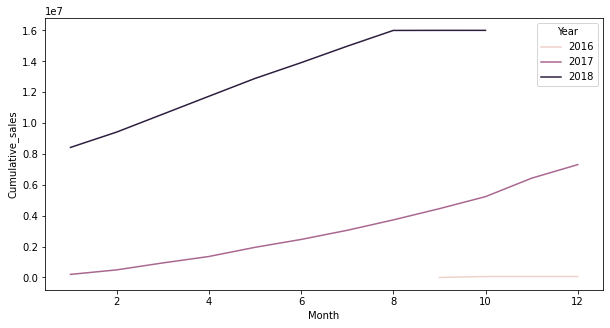

In [104]:
plt.figure(figsize = (10,5))
sns.lineplot(data = cum_sales, x='Month', y='Cumulative_sales',hue = 'Year')
plt.show()

In [108]:
#Year over year growth rate

query = """select years, payment, lag(payment,1) over(order by years) as prev_year
from
(select year(orders.order_purchase_timestamp) as years, 
round(sum(payments.payment_value),2) as payment from orders
join payments 
on orders.order_id = payments.order_id
group by years order by years) as a"""
cur.execute(query)
data = cur.fetchall()
data

[(2016, 59362.34, None),
 (2017, 7249746.73, 59362.34),
 (2018, 8699763.05, 7249746.73)]

In [109]:
yearly_sales = pd.DataFrame(data, columns=['Year','Sales','Previous_year_sales'])
yearly_sales

,Year,Sales,Previous_year_sales
0,2016,59362.34,NaN
1,2017,7249746.73,59362.34
2,2018,8699763.05,7249746.73


In [110]:
yoy_growth = (yearly_sales.Sales - yearly_sales.Previous_year_sales)*100/yearly_sales.Previous_year_sales
yoy_growth

0             NaN
1    12112.703761
2       20.000924
dtype: float64

In [120]:
yearly_sales['yoy_growth'] = yoy_growth

In [121]:
yearly_sales

,Year,Sales,Previous_year_sales,yoy_growth
0,2016,59362.34,NaN,NaN
1,2017,7249746.73,59362.34,12112.703761
2,2018,8699763.05,7249746.73,20.000924


In [134]:
#Customers who spend the most money each year

query = """select years, customer_id, payment, ranks from
(select year(orders.order_purchase_timestamp) as years, orders.customer_id, round(sum(payments.payment_value),2) as payment,
dense_rank() over(partition by year(orders.order_purchase_timestamp) order by sum(payments.payment_value) desc) as ranks
from orders join payments
on orders.order_id = payments.order_id
group by year(orders.order_purchase_timestamp), orders.customer_id) as a
where ranks<=5"""
cur.execute(query)
data = cur.fetchall()
data

[(2016, 'a9dc96b027d1252bbac0a9b72d837fc6', 1423.55, 1),
 (2016, '1d34ed25963d5aae4cf3d7f3a4cda173', 1400.74, 2),
 (2016, '4a06381959b6670756de02e07b83815f', 1227.78, 3),
 (2016, '1fc56719b52f82c03caddc5faf531fbb', 982.41, 4),
 (2016, '85f0e92957e9fb9c5f72ba5378f492a0', 979.91, 5),
 (2017, '1617b1357756262bfa56ab541c47bc16', 13664.08, 1),
 (2017, 'c6e2731c5b391845f6800c97401a43a9', 6929.31, 2),
 (2017, '3fd6777bbce08a352fddd04e4a7cc8f6', 6726.66, 3),
 (2017, '05455dfa7cd02f13d132aa7a6a9729c6', 6081.54, 4),
 (2017, 'df55c14d1476a9a3467f131269c2477f', 4950.34, 5),
 (2018, 'ec5b2ba62e574342386871631fafd3fc', 7274.88, 1),
 (2018, 'f48d464a0baaea338cb25f816991ab1f', 6922.21, 2),
 (2018, 'e0a2412720e9ea4f26c1ac985f6a7358', 4809.44, 3),
 (2018, '3d979689f636322c62418b6346b1c6d2', 4681.78, 4),
 (2018, '1afc82cd60e303ef09b4ef9837c9505c', 4513.32, 5)]

In [137]:
top_customers = pd.DataFrame(data, columns=['Years','Customer_ID','Payment','Rank'])
top_customers

,Years,Customer_ID,Payment,Rank
0,2016,a9dc96b027d1252bbac0a9b72d837fc6,1423.55,1
1,2016,1d34ed25963d5aae4cf3d7f3a4cda173,1400.74,2
2,2016,4a06381959b6670756de02e07b83815f,1227.78,3
3,2016,1fc56719b52f82c03caddc5faf531fbb,982.41,4
4,2016,85f0e92957e9fb9c5f72ba5378f492a0,979.91,5
5,2017,1617b1357756262bfa56ab541c47bc16,13664.08,1
6,2017,c6e2731c5b391845f6800c97401a43a9,6929.31,2
7,2017,3fd6777bbce08a352fddd04e4a7cc8f6,6726.66,3
8,2017,05455dfa7cd02f13d132aa7a6a9729c6,6081.54,4
9,2017,df55c14d1476a9a3467f131269c2477f,4950.34,5


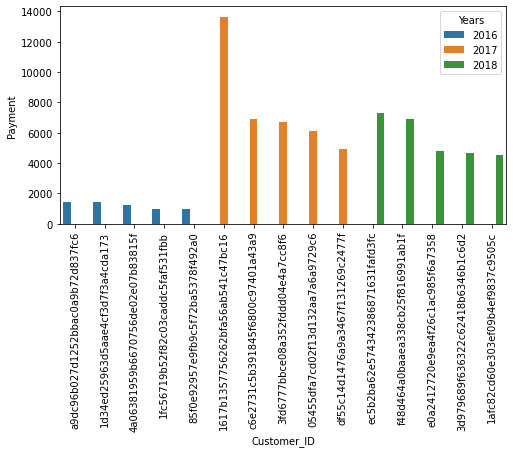

In [140]:
plt.figure(figsize = (8,4))
sns.barplot(x = 'Customer_ID', y = 'Payment', data = top_customers, hue = 'Years')
plt.xticks(rotation = 90)
plt.show()